In [10]:
import glob
import re

codes = []
for filepath in glob.glob('../logs_tests/_test_pg18_*.log'):
    if 'load' in filepath:
        continue
    with open(filepath, encoding='utf-16') as f:
        for _line in f:
            _m = re.search(r"Experiment\s+: has code (\d+)", _line)
            if _m:
                codes.append(str(_m.group(1)))
                break

print(codes)


['1779588138', '1779542125', '1779597697', '1779553188', '1779607391', '1779564518', '1779617086', '1779575726']


In [11]:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option('display.max_colwidth', None)
pd.options.display.max_columns = None
pd.options.display.max_rows = None
pd.options.display.float_format = '{:.2f}'.format

from bexhoma import collectors

%matplotlib inline

In [12]:
path = r"D:\data\benchmarks"
#path = r"/data/benchmarks"
filename_prefix = "demo_"
b_plot_save = False
b_skip_plots = True

In [13]:
collect = collectors.benchbase(path, codes)

In [14]:
collect.get_metrics_metadata()

,title,active,type,metric
total_cpu_memory,Memory Usage [MiB],True,cluster,gauge
total_cpu_memory_cached,Memory Usage Cached [MiB],True,cluster,gauge
total_cpu_util,CPU Utilization,True,cluster,gauge
total_cpu_throttled,CPU Throttle,True,cluster,gauge
total_cpu_throttled_s,CPU Throttled Time [s],True,cluster,counter
total_cpu_util_others,CPU Utilization Others,False,cluster,gauge
total_cpu_util_s,CPU Utilization Time [s],True,cluster,counter
total_cpu_util_user_s,CPU User Time [s],True,cluster,counter
total_cpu_util_sys_s,CPU System Time [s],True,cluster,counter
total_cpu_util_others_s,CPU Utilization Time Others [s],False,cluster,counter


In [16]:
df_performance = collect.get_performance_aggregated_per_phase()

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance.dropna(inplace=True)

In [17]:
df_performance

,phase,configuration,experiment_run,client,code,pod_count,duration,bench,profile,target,time,batchsize,sf,num_errors,scalefactor,Current Timestamp (milliseconds),Benchmark Type,isolation,DBMS Version,Goodput (requests/second),terminals,DBMS Type,Throughput (requests/second),Latency Distribution.95th Percentile Latency (microseconds),Latency Distribution.Maximum Latency (microseconds),Latency Distribution.Median Latency (microseconds),Latency Distribution.Minimum Latency (microseconds),Latency Distribution.25th Percentile Latency (microseconds),Latency Distribution.90th Percentile Latency (microseconds),Latency Distribution.99th Percentile Latency (microseconds),Latency Distribution.75th Percentile Latency (microseconds),Latency Distribution.Average Latency (microseconds),efficiency,child
1779588138-PostgreSQL-1-1-1,1779588138-PostgreSQL-1-1-1,1779588138-PostgreSQL-1,1,1,1779588138,1,2403,tpcc,postgres,16384,2400.00,128.00,160,0,160,1779590708392,tpcc,TRANSACTION_READ_COMMITTED,"PostgreSQL 18.3 (Debian 18.3-1.pgdg13+1) on x86_64-pc-linux-gnu, compiled by gcc (Debian 14.2.0-19) 14.2.0, 64-bit",141.38,16,POSTGRES,142.04,384523.00,12444565.00,63506.00,746.00,24854.00,263436.00,742190.00,137418.00,112629.00,0.00,1
1779588138-PostgreSQL-1-2-1,1779588138-PostgreSQL-1-2-1,1779588138-PostgreSQL-1,2,1,1779588138,1,2404,tpcc,postgres,16384,2400.00,128.00,160,0,160,1779593437062,tpcc,TRANSACTION_READ_COMMITTED,"PostgreSQL 18.3 (Debian 18.3-1.pgdg13+1) on x86_64-pc-linux-gnu, compiled by gcc (Debian 14.2.0-19) 14.2.0, 64-bit",142.23,16,POSTGRES,142.89,394316.00,12728796.00,58971.00,777.00,23276.00,262074.00,834348.00,132226.00,111949.00,0.00,1
1779588138-PostgreSQL-1-3-1,1779588138-PostgreSQL-1-3-1,1779588138-PostgreSQL-1,3,1,1779588138,1,2404,tpcc,postgres,16384,2400.00,128.00,160,0,160,1779596124798,tpcc,TRANSACTION_READ_COMMITTED,"PostgreSQL 18.3 (Debian 18.3-1.pgdg13+1) on x86_64-pc-linux-gnu, compiled by gcc (Debian 14.2.0-19) 14.2.0, 64-bit",133.64,16,POSTGRES,134.24,444455.00,12214518.00,58211.00,745.00,22798.00,309545.00,835514.00,138321.00,119181.00,0.00,1
1779542125-PostgreSQL-1-1-1,1779542125-PostgreSQL-1-1-1,1779542125-PostgreSQL-1,1,1,1779542125,1,2415,tpcc,postgres,16384,2400.00,128.00,160,0,160,1779545668943,tpcc,TRANSACTION_READ_COMMITTED,"PostgreSQL 18.3 (Debian 18.3-1.pgdg13+1) on x86_64-pc-linux-gnu, compiled by gcc (Debian 14.2.0-19) 14.2.0, 64-bit",1768.21,16,POSTGRES,1776.22,22366.00,78076.00,6301.00,720.00,3181.00,17964.00,36292.00,13326.00,9005.00,0.00,1
1779542125-PostgreSQL-1-2-1,1779542125-PostgreSQL-1-2-1,1779542125-PostgreSQL-1,2,1,1779542125,1,2414,tpcc,postgres,16384,2400.00,128.00,160,0,160,1779549403553,tpcc,TRANSACTION_READ_COMMITTED,"PostgreSQL 18.3 (Debian 18.3-1.pgdg13+1) on x86_64-pc-linux-gnu, compiled by gcc (Debian 14.2.0-19) 14.2.0, 64-bit",1807.71,16,POSTGRES,1815.84,20520.00,81150.00,6261.00,735.00,3187.00,17123.00,31855.00,13192.00,8809.00,0.00,1
1779542125-PostgreSQL-1-3-1,1779542125-PostgreSQL-1-3-1,1779542125-PostgreSQL-1,3,1,1779542125,1,2415,tpcc,postgres,16384,2400.00,128.00,160,0,160,1779553078973,tpcc,TRANSACTION_READ_COMMITTED,"PostgreSQL 18.3 (Debian 18.3-1.pgdg13+1) on x86_64-pc-linux-gnu, compiled by gcc (Debian 14.2.0-19) 14.2.0, 64-bit",1800.22,16,POSTGRES,1808.26,20973.00,86466.00,6097.00,710.00,3209.00,17445.00,33463.00,13185.00,8846.00,0.00,1
1779597697-PostgreSQL-1-1-1,1779597697-PostgreSQL-1-1-1,1779597697-PostgreSQL-1,1,1,1779597697,1,2404,tpcc,postgres,16384,2400.00,128.00,160,0,160,1779600267875,tpcc,TRANSACTION_READ_COMMITTED,"PostgreSQL 18.3 (Debian 18.3-1.pgdg13+1) on x86_64-pc-linux-gnu, compiled by gcc (Debian 14.2.0-19) 14.2.0, 64-bit",132.57,16,POSTGRES,133.16,411819.00,9725892.00,64647.00,747.00,23905.00,302466.00,698155.00,160402.00,120149.00,0.00,1
1779597697-PostgreSQL-1-2-1,1779597697-PostgreSQL-1-2-1,1779597697-PostgreSQL-1,2,1,1779597697,1,2404,tpcc,postgres,16384,2400.00,128.00,160,0,160,1779602986529,tpcc,TRANSACTION_READ_COMMITTED,"PostgreSQL 18.3 (Debian 1

In [18]:
df = collect.add_metadata(df_performance)
df.T

add_metadata: combine on index and column 'phase'


phase,1779588138-PostgreSQL-1-1-1,1779588138-PostgreSQL-1-2-1,1779588138-PostgreSQL-1-3-1,1779542125-PostgreSQL-1-1-1,1779542125-PostgreSQL-1-2-1,1779542125-PostgreSQL-1-3-1,1779597697-PostgreSQL-1-1-1,1779597697-PostgreSQL-1-2-1,1779597697-PostgreSQL-1-3-1,1779553188-PostgreSQL-1-1-1,1779553188-PostgreSQL-1-2-1,1779553188-PostgreSQL-1-3-1,1779607391-PostgreSQL-1-1-1,1779607391-PostgreSQL-1-2-1,1779607391-PostgreSQL-1-3-1,1779564518-PostgreSQL-1-1-1,1779564518-PostgreSQL-1-2-1,1779564518-PostgreSQL-1-3-1,1779617086-PostgreSQL-1-1-1,1779617086-PostgreSQL-1-2-1,1779617086-PostgreSQL-1-3-1,1779575726-PostgreSQL-1-1-1,1779575726-PostgreSQL-1-2-1,1779575726-PostgreSQL-1-3-1
configuration,1779588138-PostgreSQL-1,1779588138-PostgreSQL-1,1779588138-PostgreSQL-1,1779542125-PostgreSQL-1,1779542125-PostgreSQL-1,1779542125-PostgreSQL-1,1779597697-PostgreSQL-1,1779597697-PostgreSQL-1,1779597697-PostgreSQL-1,1779553188-PostgreSQL-1,1779553188-PostgreSQL-1,1779553188-PostgreSQL-1,1779607391-PostgreSQL-1,1779607391-PostgreSQL-1,1779607391-PostgreSQL-1,1779564518-PostgreSQL-1,1779564518-PostgreSQL-1,1779564518-PostgreSQL-1,1779617086-PostgreSQL-1,1779617086-PostgreSQL-1,1779617086-PostgreSQL-1,1779575726-PostgreSQL-1,1779575726-PostgreSQL-1,1779575726-PostgreSQL-1
experiment_run,1,2,3,1,2,3,1,2,3,1,2,3,1,2,3,1,2,3,1,2,3,1,2,3
client,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
code,1779588138,1779588138,1779588138,1779542125,1779542125,1779542125,1779597697,1779597697,1779597697,1779553188,1779553188,1779553188,1779607391,1779607391,1779607391,1779564518,1779564518,1779564518,1779617086,1779617086,1779617086,1779575726,1779575726,1779575726
pod_count,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
duration,2403,2404,2404,2415,2414,2415,2404,2404,2403,2415,2415,2415,2404,2404,2404,2415,2415,2415,2405,2404,2404,2415,2414,2415
bench,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc
profile,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres
target,16384,16384,16384,16384,16384,16384,16384,16384,16384,16384,16384,16384,16384,16384,16384,16384,16384,16384,16384,16384,16384,16384,16384,16384
time,2400.00,2400.00,2400.00,2400.00,2400.00,2400.00,2400.00,2400.00,2400.00,2400.00,2400.00,2400.00,2400.00,2400.00,2400.00,2400.00,2400.00,2400.00,2400.00,2400.00,2400.00,2400.00,2400.00,2400.00


In [19]:
collectors.get_non_constant(df).T

phase,1779588138-PostgreSQL-1-1-1,1779588138-PostgreSQL-1-2-1,1779588138-PostgreSQL-1-3-1,1779542125-PostgreSQL-1-1-1,1779542125-PostgreSQL-1-2-1,1779542125-PostgreSQL-1-3-1,1779597697-PostgreSQL-1-1-1,1779597697-PostgreSQL-1-2-1,1779597697-PostgreSQL-1-3-1,1779553188-PostgreSQL-1-1-1,1779553188-PostgreSQL-1-2-1,1779553188-PostgreSQL-1-3-1,1779607391-PostgreSQL-1-1-1,1779607391-PostgreSQL-1-2-1,1779607391-PostgreSQL-1-3-1,1779564518-PostgreSQL-1-1-1,1779564518-PostgreSQL-1-2-1,1779564518-PostgreSQL-1-3-1,1779617086-PostgreSQL-1-1-1,1779617086-PostgreSQL-1-2-1,1779617086-PostgreSQL-1-3-1,1779575726-PostgreSQL-1-1-1,1779575726-PostgreSQL-1-2-1,1779575726-PostgreSQL-1-3-1
configuration,1779588138-PostgreSQL-1,1779588138-PostgreSQL-1,1779588138-PostgreSQL-1,1779542125-PostgreSQL-1,1779542125-PostgreSQL-1,1779542125-PostgreSQL-1,1779597697-PostgreSQL-1,1779597697-PostgreSQL-1,1779597697-PostgreSQL-1,1779553188-PostgreSQL-1,1779553188-PostgreSQL-1,1779553188-PostgreSQL-1,1779607391-PostgreSQL-1,1779607391-PostgreSQL-1,1779607391-PostgreSQL-1,1779564518-PostgreSQL-1,1779564518-PostgreSQL-1,1779564518-PostgreSQL-1,1779617086-PostgreSQL-1,1779617086-PostgreSQL-1,1779617086-PostgreSQL-1,1779575726-PostgreSQL-1,1779575726-PostgreSQL-1,1779575726-PostgreSQL-1
experiment_run,1,2,3,1,2,3,1,2,3,1,2,3,1,2,3,1,2,3,1,2,3,1,2,3
code,1779588138,1779588138,1779588138,1779542125,1779542125,1779542125,1779597697,1779597697,1779597697,1779553188,1779553188,1779553188,1779607391,1779607391,1779607391,1779564518,1779564518,1779564518,1779617086,1779617086,1779617086,1779575726,1779575726,1779575726
duration,2403,2404,2404,2415,2414,2415,2404,2404,2403,2415,2415,2415,2404,2404,2404,2415,2415,2415,2405,2404,2404,2415,2414,2415
Current Timestamp (milliseconds),1779590708392,1779593437062,1779596124798,1779545668943,1779549403553,1779553078973,1779600267875,1779602986529,1779605678161,1779556810332,1779560522409,1779564408229,1779609960904,1779612683180,1779615404130,1779568184138,1779571809821,1779575593426,1779619691863,1779622420818,1779625146882,1779579244011,1779582871678,1779586539194
Goodput (requests/second),141.38,142.23,133.64,1768.21,1807.71,1800.22,132.57,152.76,152.42,1780.45,1793.85,1795.25,152.73,126.62,122.71,1767.73,1751.77,1767.69,118.44,119.26,121.43,1784.10,1789.68,1811.26
Throughput (requests/second),142.04,142.89,134.24,1776.22,1815.84,1808.26,133.16,153.45,153.10,1788.53,1801.95,1803.45,153.41,127.22,123.26,1775.66,1759.57,1775.74,118.97,119.81,121.99,1792.13,1797.66,1819.36
Latency Distribution.95th Percentile Latency (microseconds),384523.00,394316.00,444455.00,22366.00,20520.00,20973.00,411819.00,380917.00,365698.00,21329.00,21024.00,21084.00,348095.00,488890.00,528423.00,21508.00,22501.00,21216.00,513552.00,469989.00,430664.00,21288.00,21108.00,21895.00
Latency Distribution.Maximum Latency (microseconds),12444565.00,12728796.00,12214518.00,78076.00,81150.00,86466.00,9725892.00,10310821.00,12617587.00,83993.00,89435.00,92827.00,12704953.00,9209853.00,11145855.00,80283.00,98572.00,98327.00,12051503.00,8245840.00,8738031.00,75050.00,92729.00,86442.00
Latency Distribution.Median Latency (microseconds),63506.00,58971.00,58211.00,6301.00,6261.00,6097.00,64647.00,53202.00,55667.00,6422.00,6379.00,6230.00,66464.00,66582.00,64566.00,6336.00,6433.00,6307.00,68140.00,74866.00,77563.00,6360.00,6410.00,6179.00


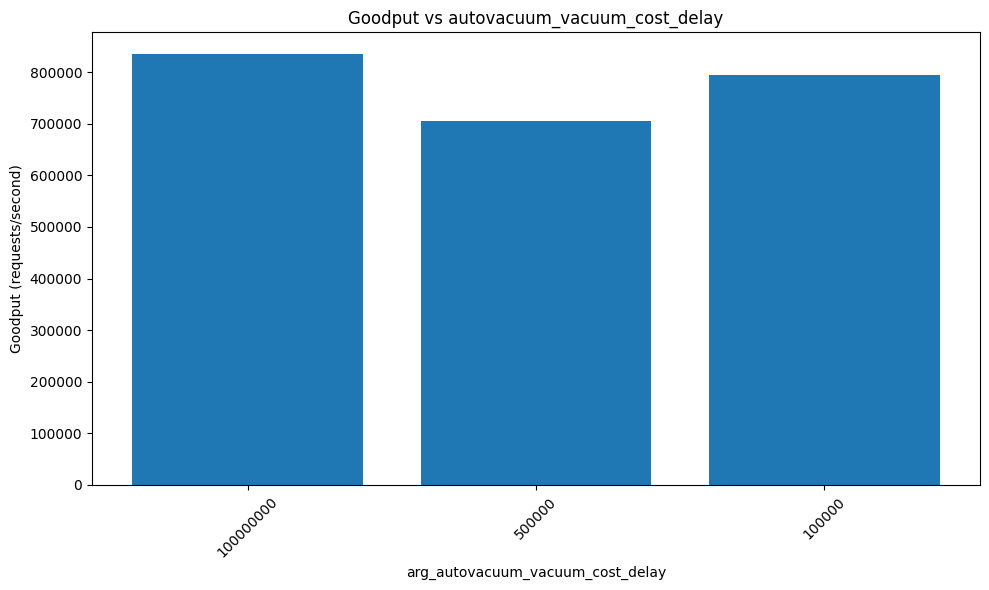

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataframe
# Example:
# df = pd.read_csv("your_file.csv")

x = df["arg_autovacuum_vacuum_cost_delay"].astype(str)
x = df["arg_autovacuum_vacuum_cost_limit"].astype(str)
x = df["arg_autovacuum_vacuum_max_threshold"].astype(str)


y = df["Goodput (requests/second)"]
y = df["Latency Distribution.99th Percentile Latency (microseconds)"]

plt.figure(figsize=(10, 6))
plt.bar(x, y)

plt.xlabel("arg_autovacuum_vacuum_cost_delay")
plt.ylabel("Goodput (requests/second)")
plt.title("Goodput vs autovacuum_vacuum_cost_delay")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

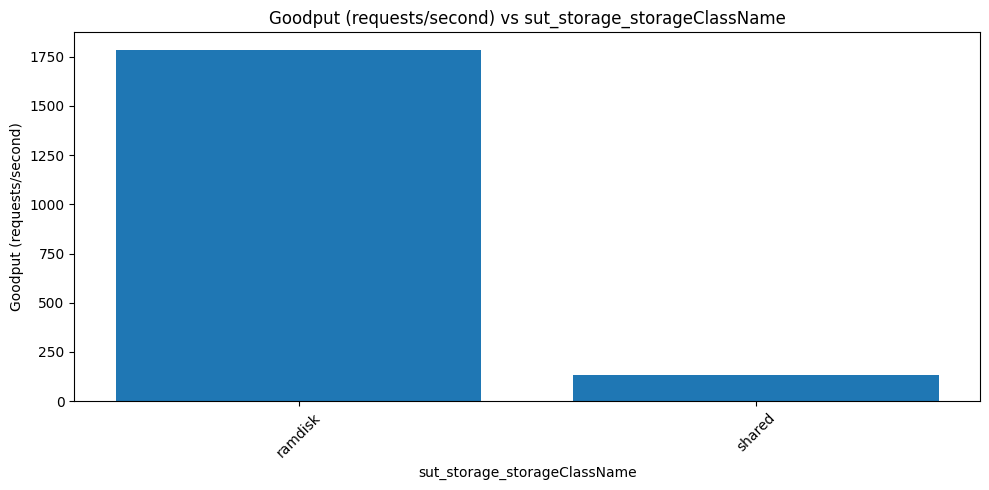

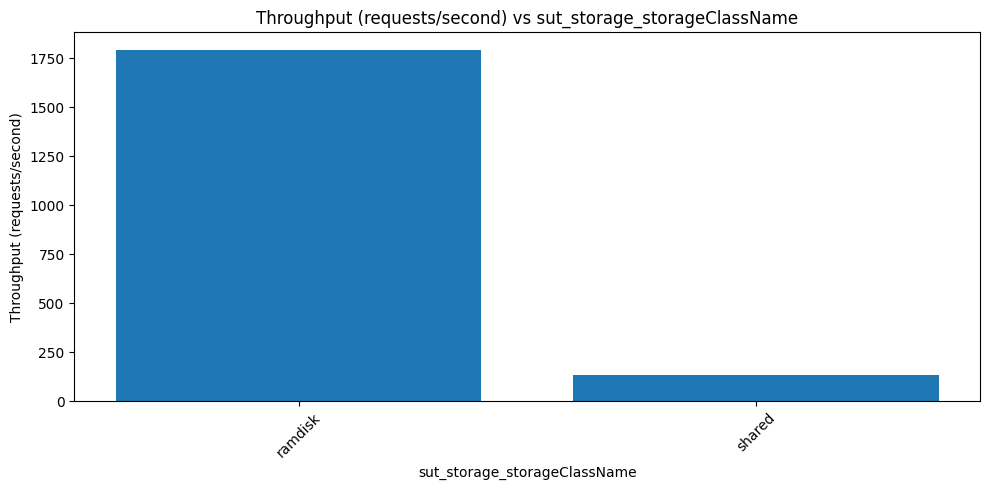

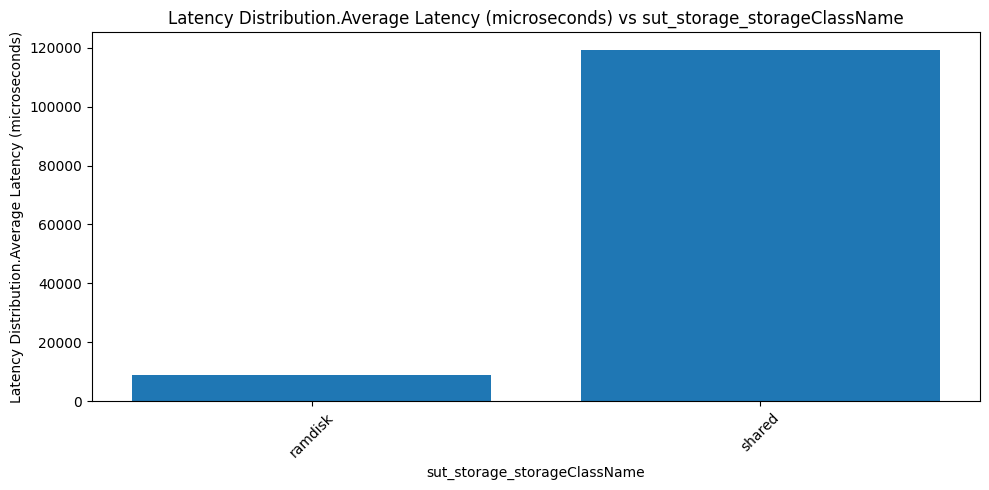

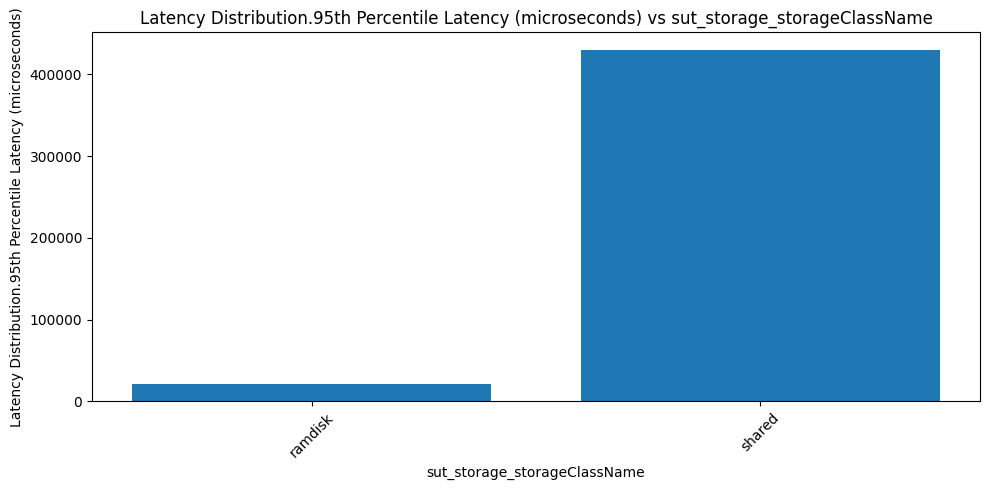

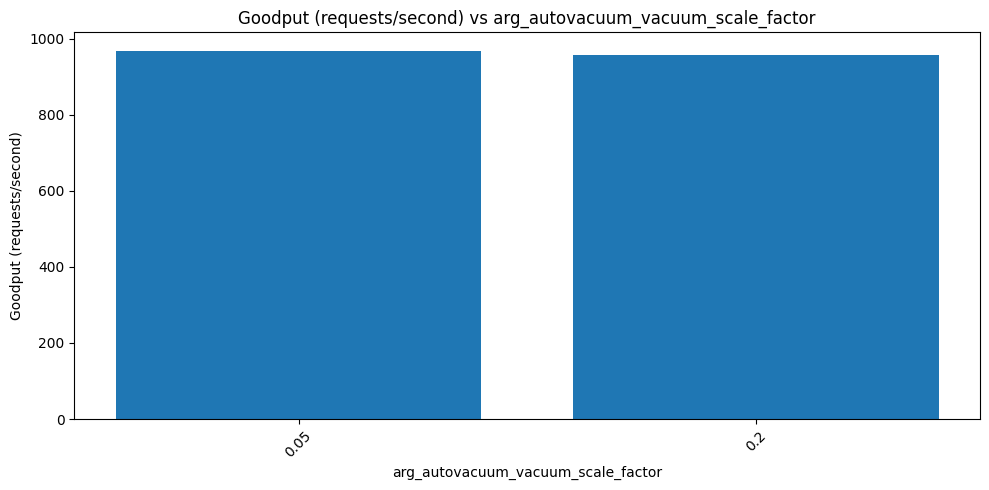

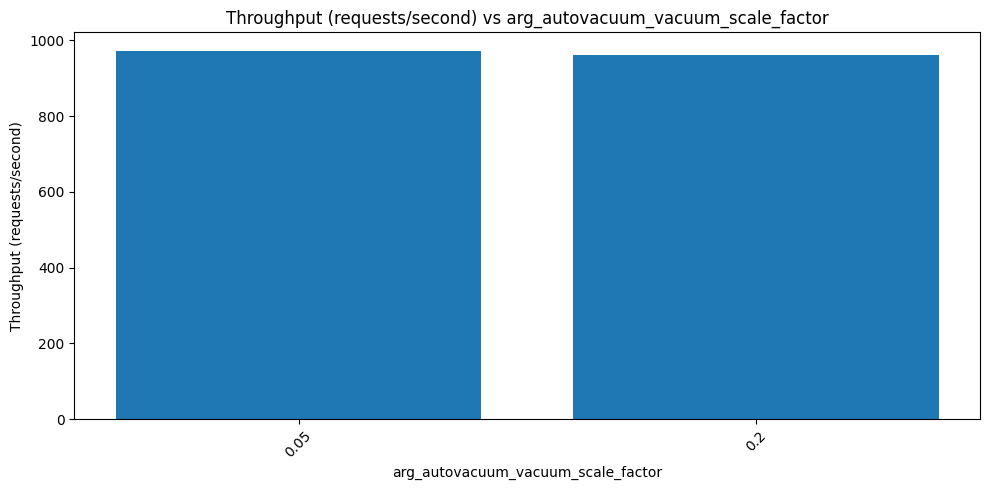

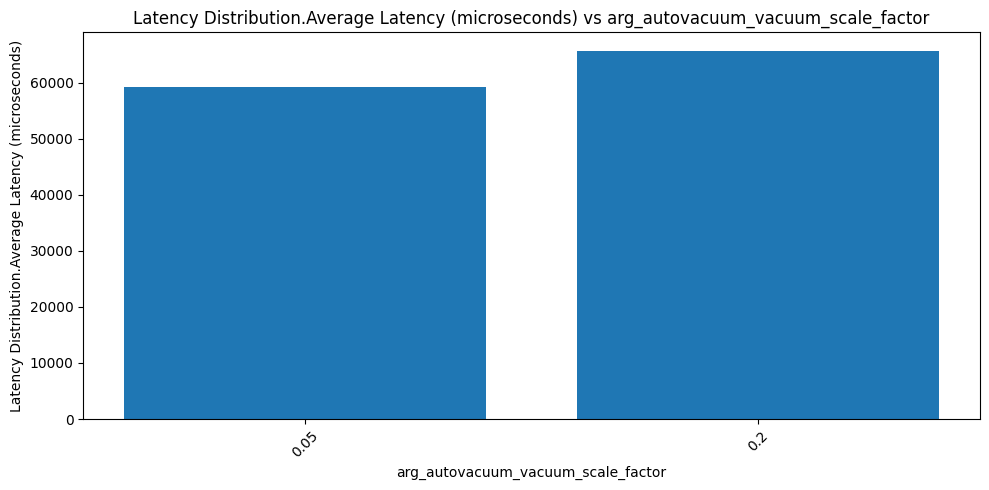

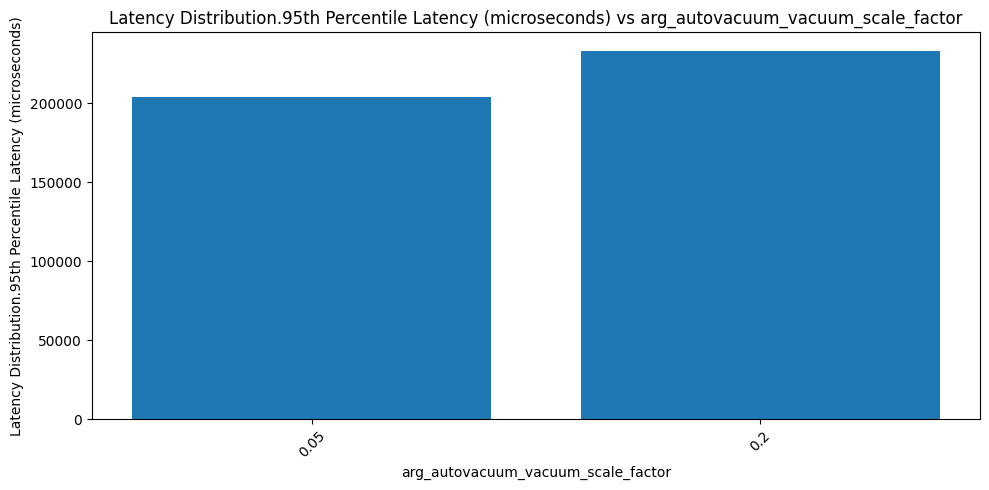

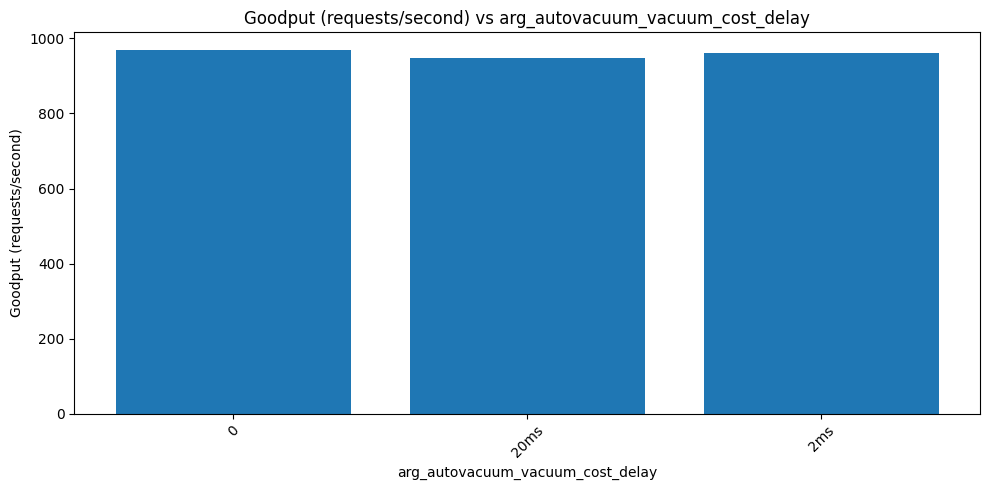

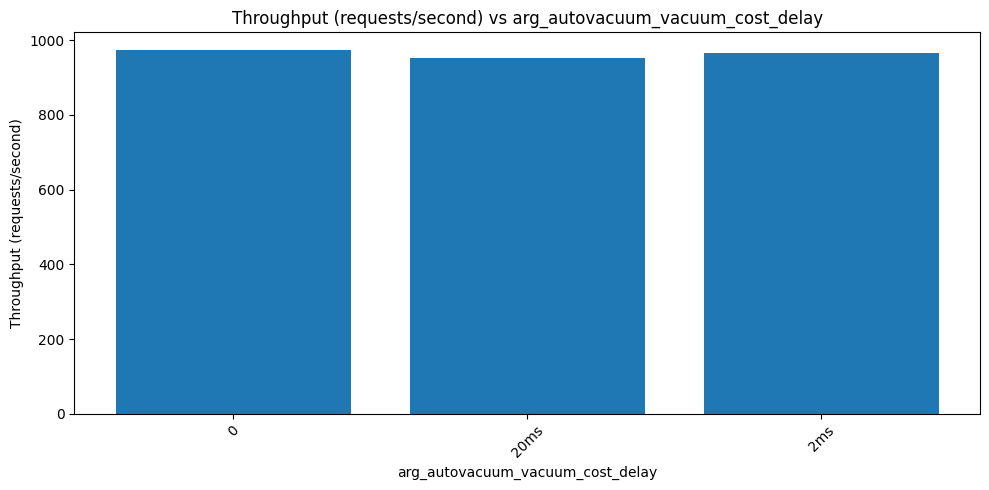

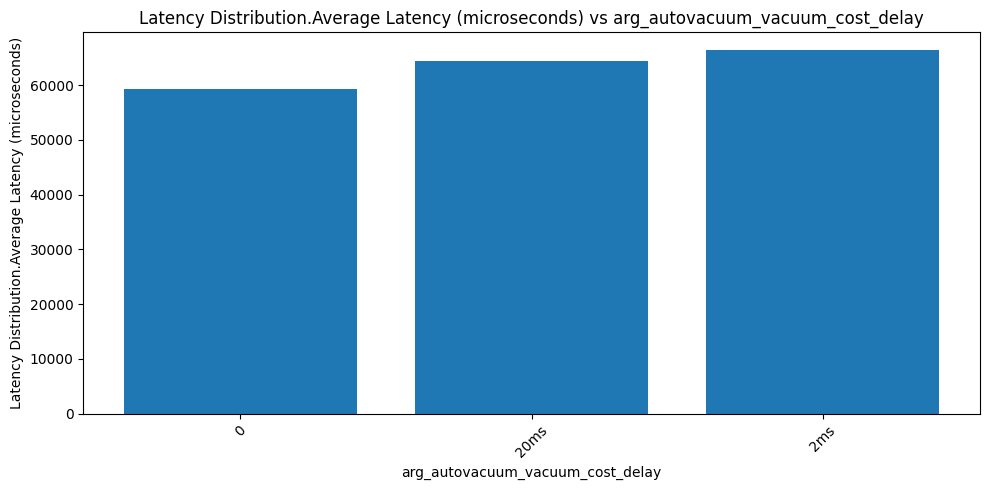

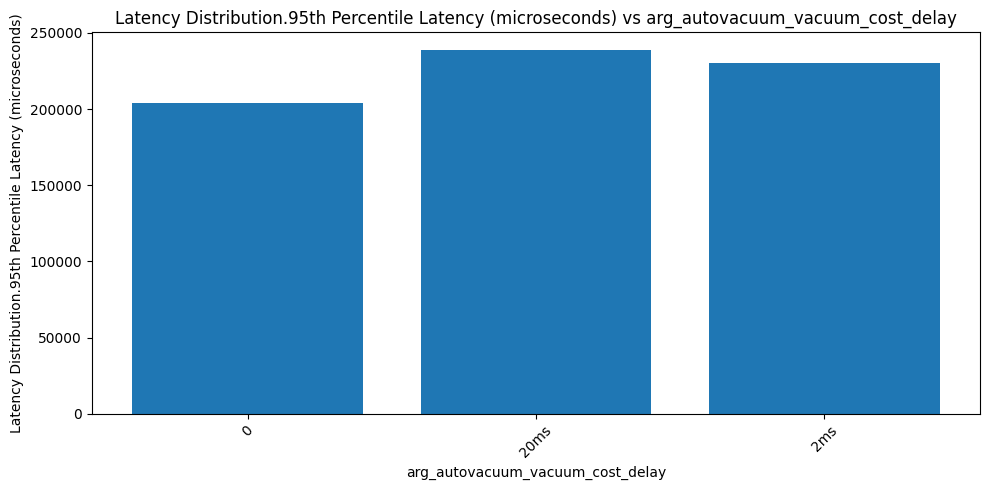

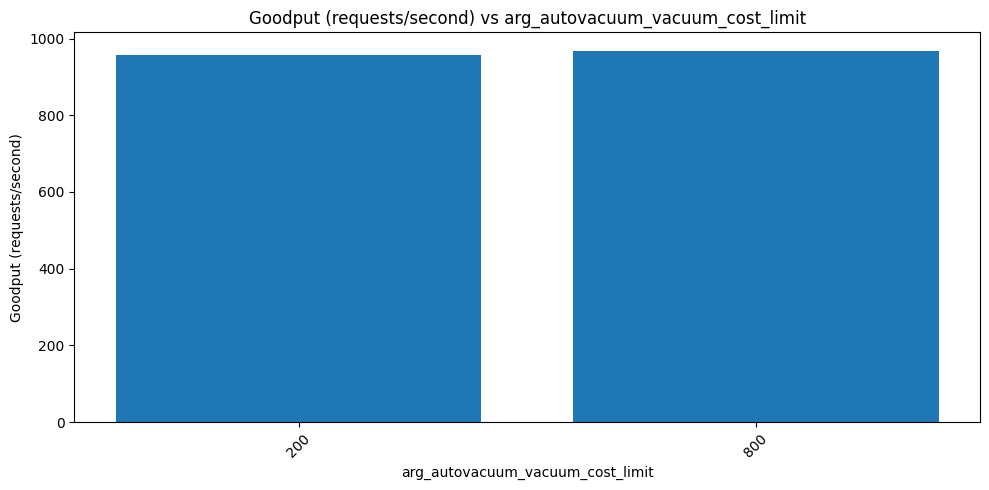

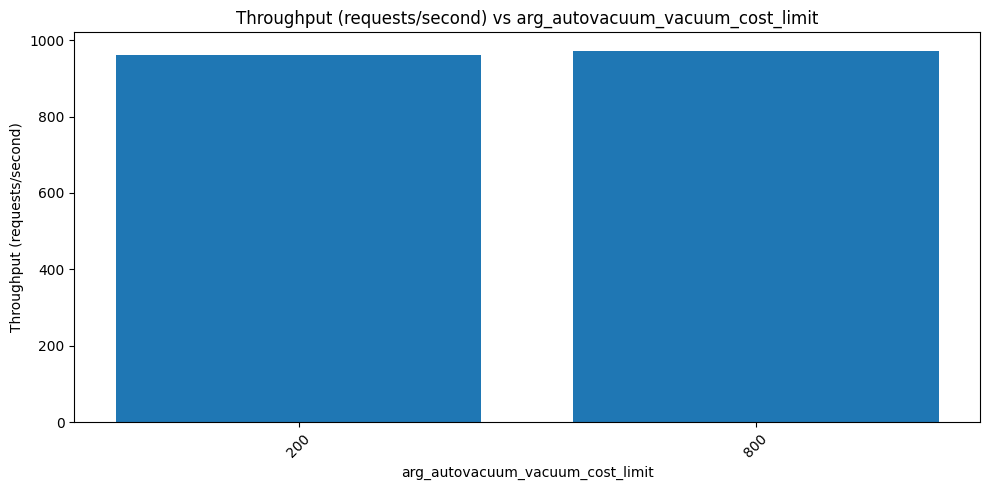

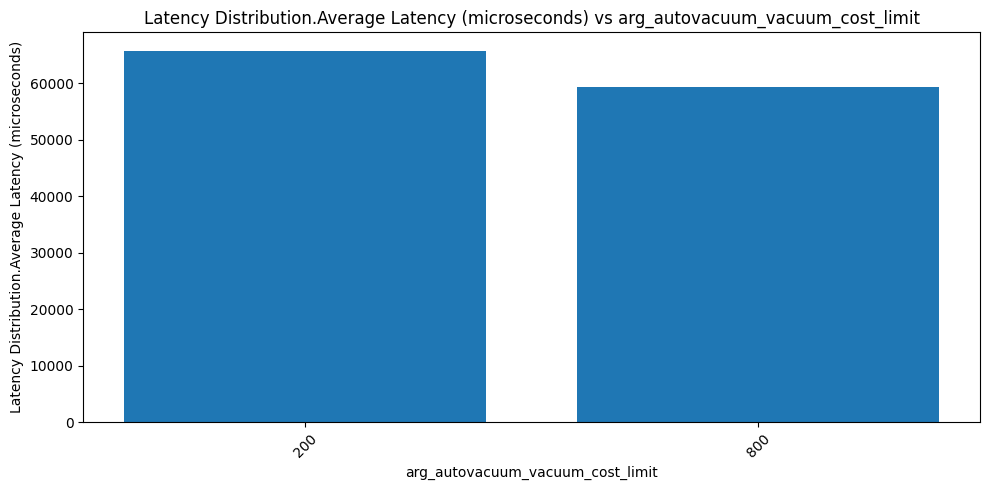

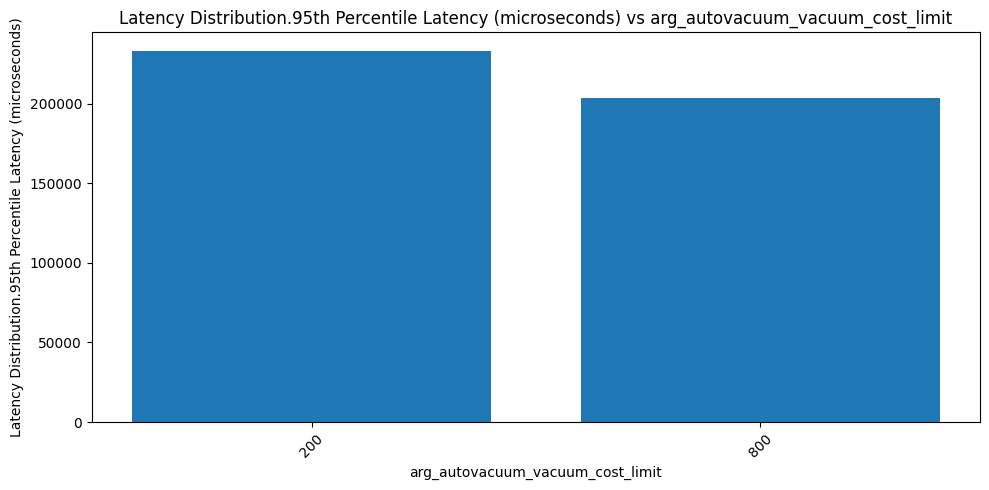

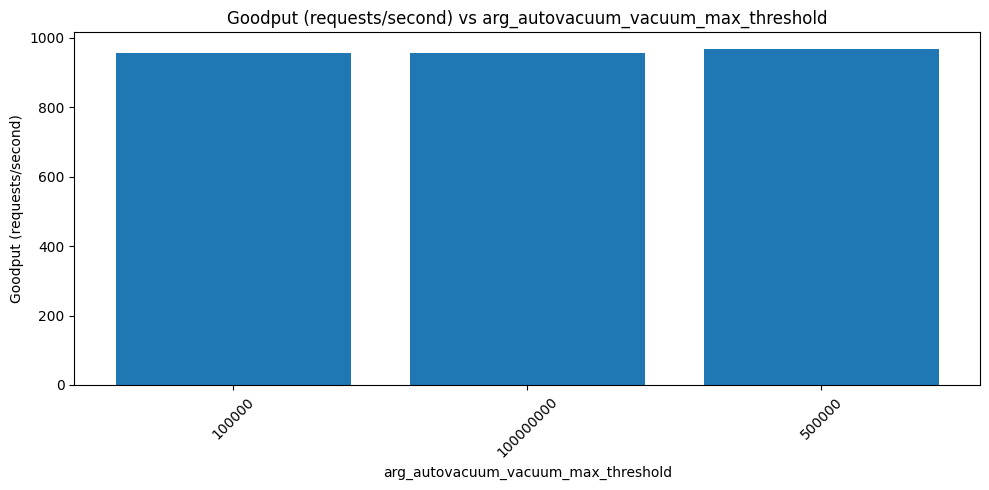

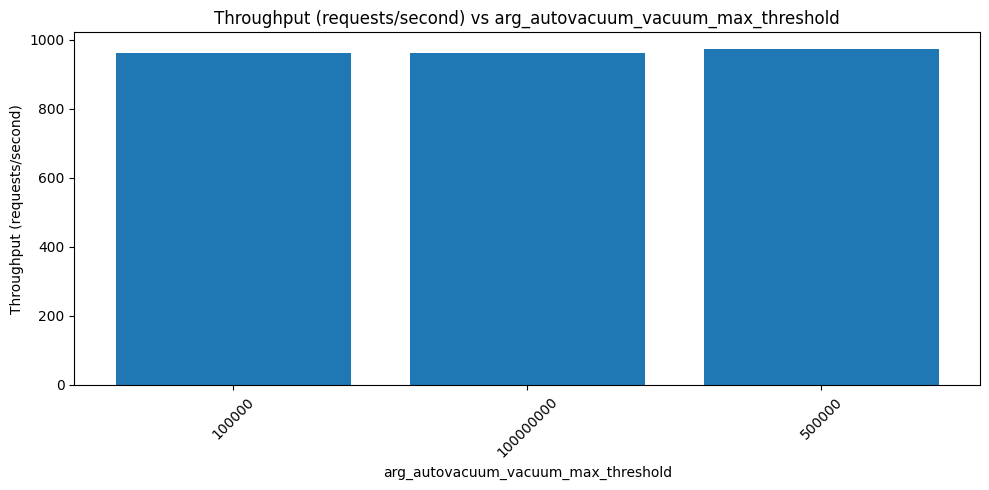

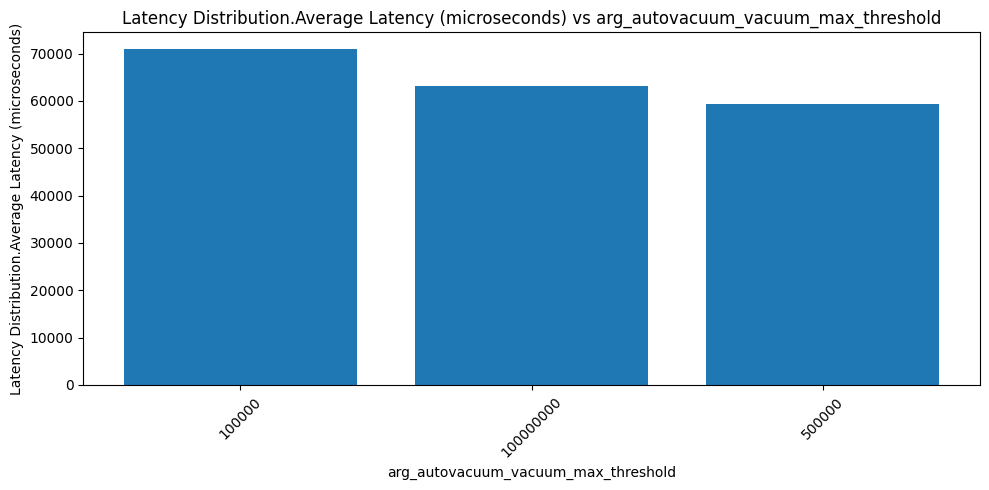

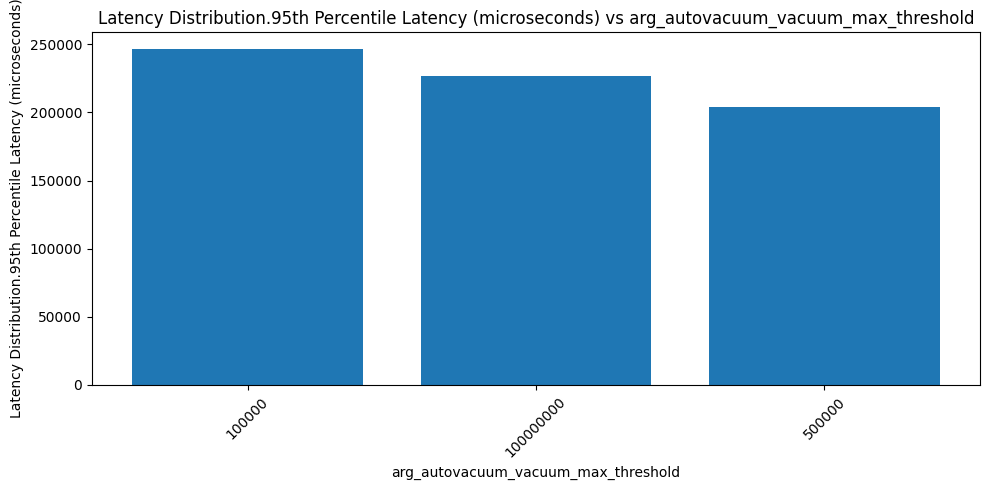

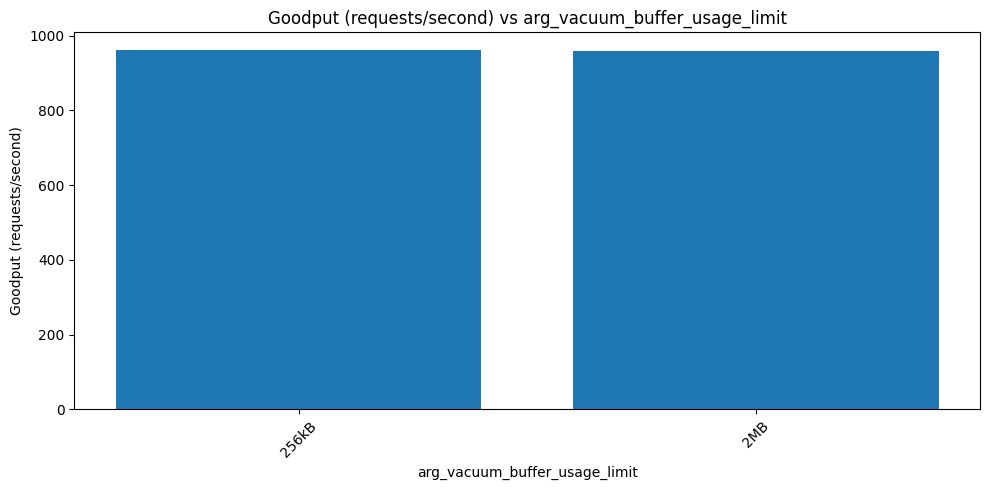

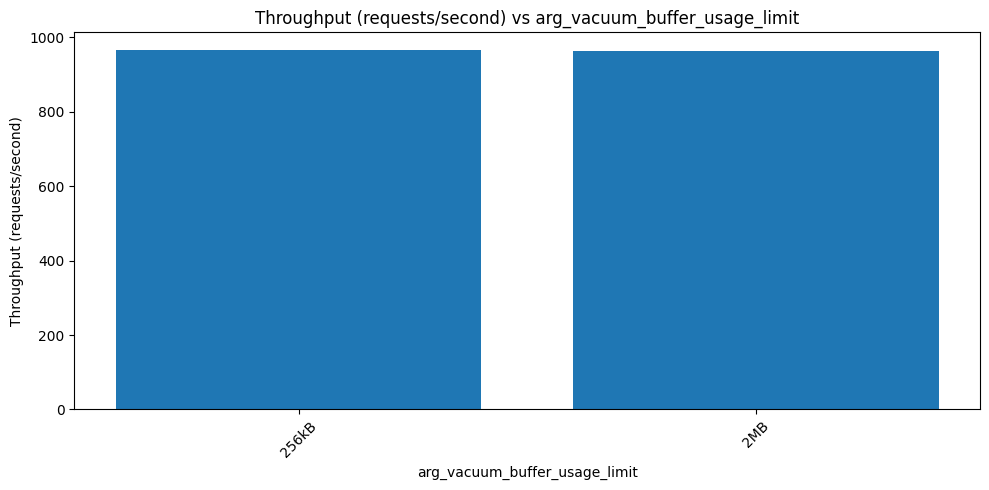

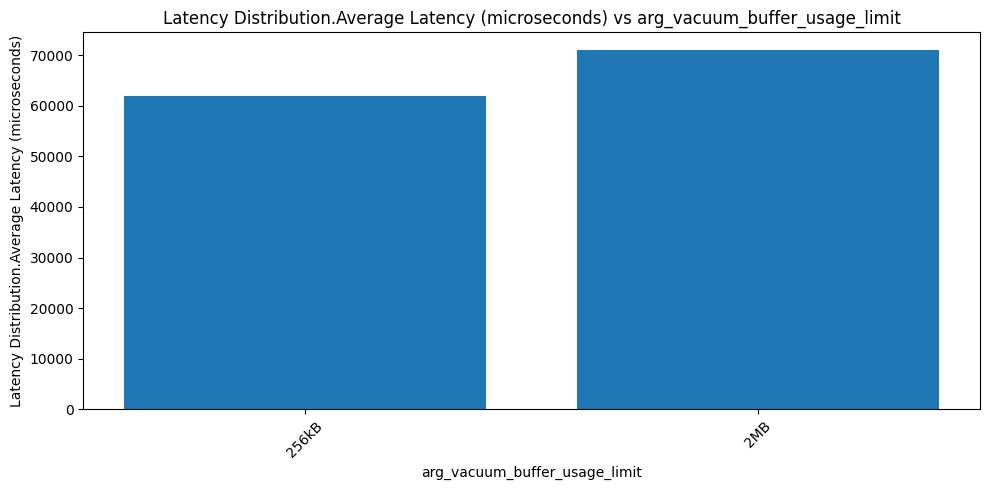

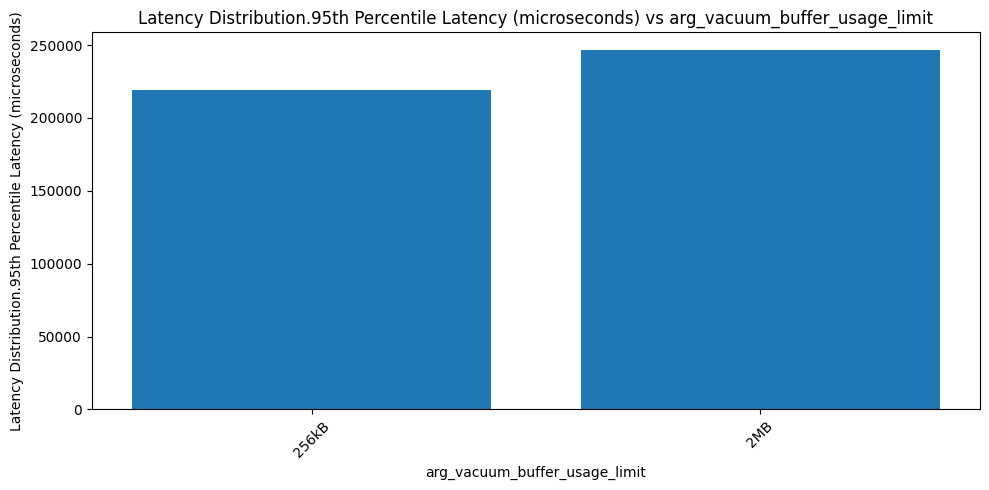

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Example:
# df = pd.read_csv("results.csv")

# -----------------------------
# Select performance metrics
# -----------------------------
metrics = [
    "Goodput (requests/second)",
    "Throughput (requests/second)",
    "Latency Distribution.Average Latency (microseconds)",
    "Latency Distribution.95th Percentile Latency (microseconds)",
]

# -----------------------------
# Select SUT parameters
# -----------------------------
sut_params = [
    "sut_storage_storageClassName",
    "arg_autovacuum_vacuum_scale_factor",
    "arg_autovacuum_vacuum_cost_delay",
    "arg_autovacuum_vacuum_cost_limit",
    "arg_autovacuum_vacuum_max_threshold",
    "arg_vacuum_buffer_usage_limit",
]

# -----------------------------
# Plot metrics against params
# -----------------------------
for param in sut_params:

    # aggregate repeated runs
    grouped = (
        df.groupby(param)[metrics]
        .mean(numeric_only=True)
        .reset_index()
    )

    # create one chart per metric
    for metric in metrics:

        plt.figure(figsize=(10, 5))

        x = grouped[param].astype(str)
        y = grouped[metric]

        plt.bar(x, y)

        plt.xlabel(param)
        plt.ylabel(metric)
        plt.title(f"{metric} vs {param}")

        plt.xticks(rotation=45)
        plt.tight_layout()

        plt.show()